# demos.qgtheta_gnn

This notebook demonstrates a minimal quantum graph neural network (qGNN) applied to power grid scenarios using the "quantum" approach. In particular, it builds a small pandapower network (a low-voltage or medium-voltage test grid) consisting of buses (nodes), lines (connections between nodes), and loads (active and reactive power consumption at buses) with the goal of predicting node voltage magnitudes from load and generation features using a two-layer qGNN (with different quantum filters). We will use the same test grid and dataset used in the demo `shallow_kipf_welling_gnn.ipynb`.

In [1]:
import os
os.chdir("..")

In [2]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandapower as pp

In [3]:
from utils.pandapower_adapter import *
from utils.graphs import build_graph_input
from quantum_gnns.qgtheta import *

## Utilities

In [4]:
def generate_voltage_dataset(base_net, n_samples=80, seed=42):
    """
    Generate node-level regression data on a fixed pandapower topology.

    Args:
        base_net: Base pandapower network.
        n_samples: Number of operating scenarios.
        seed: Random seed.

    Returns:
        X: Input array of shape (num_samples, num_nodes, 1).
        Y: Target array of shape (num_samples, num_nodes, 1).
    """
    rng = np.random.default_rng(seed)
    X_list = []
    Y_list = []
    for _ in range(n_samples):
        net = copy.deepcopy(base_net)
        for load_idx in net.load.index:
            p = rng.uniform(0.2, 1.2)
            q = 0.2 * p
            net.load.loc[load_idx, "p_mw"] = p
            net.load.loc[load_idx, "q_mvar"] = q
        pp.runpp(net)
        node_order = list(map(int, net.bus.index))
        x = np.zeros((len(node_order), 1), dtype=np.float64)
        for _, row in net.load.iterrows():
            bus_idx = int(row["bus"])
            x[bus_idx, 0] += float(row["p_mw"])
        y = net.res_bus.loc[node_order, "vm_pu"].to_numpy(dtype=np.float64).reshape(-1, 1)
        X_list.append(x)
        Y_list.append(y)
    X = np.stack(X_list, axis=0)
    Y = np.stack(Y_list, axis=0)
    return X, Y

In [5]:
def pack_parameters(qgnn, provider_1, provider_2):
    """
    Flatten all trainable parameters into one vector.
    """
    parts = [provider_1.get_parameter_vector(),provider_2.get_parameter_vector(),
             qgnn.layer1.weight.reshape(-1),qgnn.layer1.bias.reshape(-1),
             qgnn.layer2.weight.reshape(-1),qgnn.layer2.bias.reshape(-1),]
    return np.concatenate(parts).astype(np.float64)


def unpack_parameters(param_vector, qgnn, provider_1, provider_2):
    """
    Write a flat parameter vector back into the network and providers.
    """
    idx = 0
    n_p1 = provider_1.num_parameters()
    provider_1.set_parameter_vector(param_vector[idx:idx + n_p1])
    idx += n_p1
    n_p2 = provider_2.num_parameters()
    provider_2.set_parameter_vector(param_vector[idx:idx + n_p2])
    idx += n_p2
    n_w1 = qgnn.layer1.weight.size
    qgnn.layer1.weight = param_vector[idx:idx + n_w1].reshape(qgnn.layer1.weight.shape).copy()
    idx += n_w1
    n_b1 = qgnn.layer1.bias.size
    qgnn.layer1.bias = param_vector[idx:idx + n_b1].reshape(qgnn.layer1.bias.shape).copy()
    idx += n_b1
    n_w2 = qgnn.layer2.weight.size
    qgnn.layer2.weight = param_vector[idx:idx + n_w2].reshape(qgnn.layer2.weight.shape).copy()
    idx += n_w2
    n_b2 = qgnn.layer2.bias.size
    qgnn.layer2.bias = param_vector[idx:idx + n_b2].reshape(qgnn.layer2.bias.shape).copy()
    idx += n_b2

In [6]:
def predict_dataset(qgnn, graph_input, X):
    """
    Run the quantum network on a dataset.

    Args:
        qgnn: TwoLayerQuantumGraphNetwork.
        graph_input: GraphInput object for the fixed topology.
        X: Array of shape (num_samples, num_nodes, in_features).

    Returns:
        Predictions of shape (num_samples, num_nodes, out_features).
    """
    outputs = []
    for s in range(X.shape[0]):
        out = qgnn.forward(graph_input, features=X[s])
        outputs.append(np.asarray(out, dtype=np.float64))
    return np.stack(outputs, axis=0)

In [7]:
def mse_loss(y_pred, y_true):
    return float(np.mean((y_pred - y_true) ** 2))


def mae_metric(y_pred, y_true):
    return float(np.mean(np.abs(y_pred - y_true)))


def rmse_metric(y_pred, y_true):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def r2_metric(y_pred, y_true):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - ss_res / ss_tot

## Test grid and dataset

In [8]:
# Pandapower demo network
base_net = pp.create_empty_network(sn_mva=100.0)
buses = [pp.create_bus(base_net, vn_kv=20.0, name=f"Bus {i}") for i in range(5)]
pp.create_ext_grid(base_net, bus=buses[0], vm_pu=1.0)
for b in buses[1:]:
    pp.create_load(base_net, bus=b, p_mw=0.5, q_mvar=0.1)
line_kwargs = dict(length_km=1.0,r_ohm_per_km=0.25,x_ohm_per_km=0.10,
                   c_nf_per_km=10.0,max_i_ka=0.40,)
for i in range(4):
    pp.create_line_from_parameters(base_net, buses[i], buses[i + 1], **line_kwargs)

In [9]:
X, Y = generate_voltage_dataset(base_net, n_samples=80, seed=42)

In [10]:
topology_bundle = pandapower_to_graph_bundle(base_net, node_feature_specs=["load_p_mw"], 
                                             edge_feature_specs=["loading_percent"], run_powerflow=True,)
graph_input = bundle_to_graph_input(topology_bundle,build_graph_input_fn=build_graph_input,)
#print("Node order:", topology_bundle.node_order)
#print("A_hat:")
#print(graph_input.kipf_welling_adjacency())

## FirstOrderQuantumFilter

We start by considering the `FirstOrderQuantumFilter` which implements a message passing of the form $(\theta_0+\theta_1\hat{A})X$ where the parameters $\theta_0,\theta_1$ can be given (dynamically) by a `QiskitVariationalCoefficientProvider`. The corresponding two-layer GNN can be trained in a straight-forward manner since the provider exposes `get_parameter_vector()` and `set_parameter_vector()`. 

This family of filters is motivated by the fact that both the unitary $X\to e^{\mathbf{\theta}\tilde{L}}X$ and the Chebyshev aprroximation $X\to \sum_k\theta_k T_k(\tilde{L})X$ belong to this family when truncated at first order in the expansion that define them. Thus, in this context, a natural question is: do quantum circuits provide useful low dimensional spectral prior (the distribution of the generated parameters is structuraly restricted by Born's rule)?

In [11]:
provider_1 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,output_scale=1.0,normalize_coefficients=False,)
provider_2 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,output_scale=1.0,normalize_coefficients=False,)

filter_1 = FirstOrderQuantumGraphFilter(theta_0=0.0,theta_1=0.0,coefficient_provider=provider_1,)
filter_2 = FirstOrderQuantumGraphFilter(theta_0=0.0,theta_1=0.0,coefficient_provider=provider_2,)

qgnn = TwoLayerQuantumGraphNetwork(in_features=1,hidden_features=4,out_features=1,
                                   first_filter=filter_1,second_filter=filter_2,random_state=42,)

### Train and test

In [12]:
n_samples = X.shape[0]
n_train = int(0.8 * n_samples)

X_train, Y_train = X[:n_train], Y[:n_train]
X_test, Y_test = X[n_train:], Y[n_train:]

In [13]:
train_history = []
def objective_function(param_vector):
    """
    Training objective used by scipy.optimize.minimize.
    """
    unpack_parameters(param_vector, qgnn, provider_1, provider_2)
    y_pred_train = predict_dataset(qgnn, graph_input, X_train)
    loss = mse_loss(y_pred_train, Y_train)
    train_history.append(loss)
    return loss

In [14]:
initial_params = pack_parameters(qgnn, provider_1, provider_2)
y_pred_train_init = predict_dataset(qgnn, graph_input, X_train)
y_pred_test_init = predict_dataset(qgnn, graph_input, X_test)

result = minimize(objective_function,x0=initial_params,method="Powell",
                  options={"maxiter": 100,"disp": True,},)

best_params = result.x.copy()
unpack_parameters(best_params, qgnn, provider_1, provider_2)
print("Optimization success:", result.success)
print("Final training loss:", result.fun)
print("Message:", result.message)

Optimization terminated successfully.
         Current function value: 0.000001
         Iterations: 53
         Function evaluations: 11494
Optimization success: True
Final training loss: 1.273695693642377e-06
Message: Optimization terminated successfully.


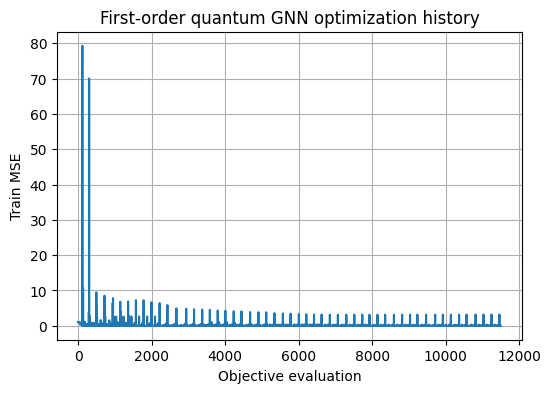

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(train_history)
plt.xlabel("Objective evaluation")
plt.ylabel("Train MSE")
plt.title("First-order quantum GNN optimization history")
plt.grid(True)
plt.show()

In [16]:
y_pred_train = predict_dataset(qgnn, graph_input, X_train)
y_pred_test = predict_dataset(qgnn, graph_input, X_test)

metrics_df = pd.DataFrame(
    {
        "split": ["train", "train", "train", "test", "test", "test"],
        "metric": ["MAE", "RMSE", "R2", "MAE", "RMSE", "R2"],
        "value": [
            mae_metric(y_pred_train, Y_train),
            rmse_metric(y_pred_train, Y_train),
            r2_metric(y_pred_train, Y_train),
            mae_metric(y_pred_test, Y_test),
            rmse_metric(y_pred_test, Y_test),
            r2_metric(y_pred_test, Y_test),
        ],
    }
)

metrics_df

,split,metric,value
0,train,MAE,0.000961
1,train,RMSE,0.001129
2,train,R2,0.636665
3,test,MAE,0.000847
4,test,RMSE,0.001063
5,test,R2,0.650018


### True vs predicted (one sample)

In [17]:
sample_x = X_test[0]
coeffs_1 = provider_1.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=2,)
coeffs_2 = provider_2.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=2,)
#print("Layer 1 coefficients [theta_0, theta_1]:", coeffs_1)
#print("Layer 2 coefficients [theta_0, theta_1]:", coeffs_2)

In [18]:
sample_idx = 0
x_sample = X_test[sample_idx].reshape(-1)
y_true = Y_test[sample_idx].reshape(-1)
y_pred = y_pred_test[sample_idx].reshape(-1)
comparison_df = pd.DataFrame(
    {
        "bus": topology_bundle.node_order,
        "load_p_mw": x_sample,
        "true_vm_pu": y_true,
        "predicted_vm_pu": y_pred,
        "abs_error": np.abs(y_true - y_pred),
    }
)
comparison_df

,bus,load_p_mw,true_vm_pu,predicted_vm_pu,abs_error
0,0,0.000000,1.000000,0.999058,0.000942
1,1,1.016569,0.998388,0.995867,0.002522
2,2,0.305278,0.997464,0.998138,0.000674
3,3,0.266559,0.996745,0.998760,0.002015
4,4,0.794434,0.996207,0.995664,0.000543


In [19]:
display_net = copy.deepcopy(base_net)
test_sample_global_idx = n_train + sample_idx
sample_loads = X[test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(display_net.load.index, display_net.load["bus"].to_numpy()):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(sample_loads[bus_idx])
    display_net.load.loc[load_idx, "p_mw"] = p
    display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

display_bundle = pandapower_to_graph_bundle(display_net,node_feature_specs=["load_p_mw"],
                                            edge_feature_specs=["loading_percent"],run_powerflow=True,)

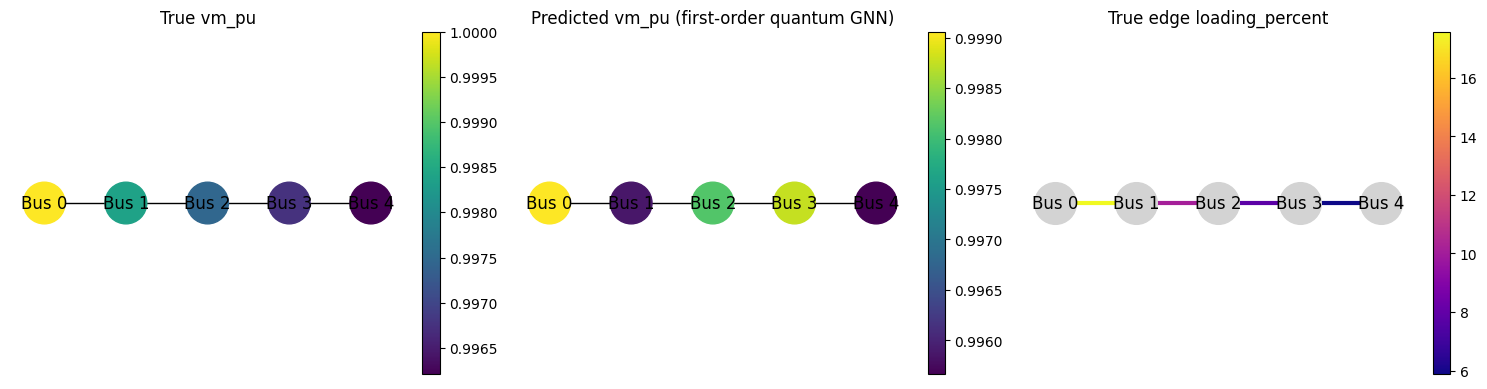

In [20]:
edge_values = np.asarray([display_bundle.edge_features[tuple(sorted((u, v)))][0] for u, v in display_bundle.graph.edges()],
                         dtype=float,)

display_graph_signal_comparison(G=display_bundle.graph,node_order=display_bundle.node_order,input_node_values=y_true,
                                output_node_values=y_pred,edge_values=edge_values,node_labels=display_bundle.node_labels,
                                layout="line",input_title="True vm_pu",output_title="Predicted vm_pu (first-order quantum GNN)",
                                edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

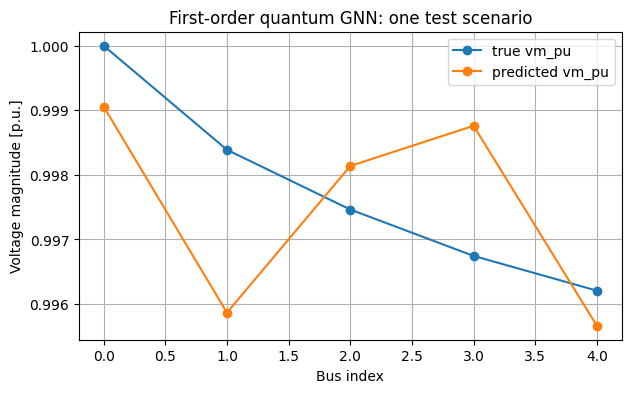

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(topology_bundle.node_order, y_true, marker="o", label="true vm_pu")
plt.plot(topology_bundle.node_order, y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("First-order quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()

## ChebyshevQuantumGraphFilter

We repeat the previous steps with the `ChebyshevQuantumGraphFilter`. In this case, we use the classical Chebyshev approximation where the parameters are generated by a quantum circuit via the `QiskitVariationalCoefficientProvider`. To fix the ideas, consider a second order Chebyshev expansion with 3 parameters $\theta_0,\theta_1,\theta_2$. The main difference between this approach and the previous `FirstOrderQuantumFilter` is that we can consider arbitrary long expansions in the Chebyshev approximation, thus going beyond the first order message passing through the normalized adjacency (or Laplacian).

In [22]:
cheb_provider_1 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,
                                                       output_scale=1.0,normalize_coefficients=False,)
cheb_provider_2 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,
                                                       output_scale=1.0,normalize_coefficients=False,)

cheb_filter_1 = ChebyshevQuantumGraphFilter(coefficients=[1.0, 0.0, 0.0],rescale_laplacian=True,coefficient_provider=cheb_provider_1,)
cheb_filter_2 = ChebyshevQuantumGraphFilter(coefficients=[1.0, 0.0, 0.0],rescale_laplacian=True,coefficient_provider=cheb_provider_2,)

cheb_qgnn = TwoLayerQuantumGraphNetwork(in_features=1,hidden_features=4,out_features=1,first_filter=cheb_filter_1,
                                        second_filter=cheb_filter_2,random_state=42,)

### Train and test

In [23]:
cheb_initial_params = pack_parameters(cheb_qgnn,cheb_provider_1,cheb_provider_2,)
cheb_y_pred_train_init = predict_dataset(cheb_qgnn, graph_input, X_train)
cheb_y_pred_test_init = predict_dataset(cheb_qgnn, graph_input, X_test)
#print("Initial Chebyshev train MSE:", mse_loss(cheb_y_pred_train_init, Y_train))
#print("Initial Chebyshev test  MSE:", mse_loss(cheb_y_pred_test_init, Y_test))

In [24]:
train_history = []
def objective_function(param_vector):
    """
    Training objective used by scipy.optimize.minimize.
    """
    unpack_parameters(param_vector, cheb_qgnn, cheb_provider_1, cheb_provider_2)
    y_pred_train = predict_dataset(cheb_qgnn, graph_input, X_train)
    loss = mse_loss(y_pred_train, Y_train)
    train_history.append(loss)
    return loss

In [25]:
cheb_result = minimize(objective_function,x0=cheb_initial_params,method="Powell",
                       options={"maxiter": 60, "disp": True,},)
cheb_best_params = cheb_result.x.copy()
unpack_parameters(cheb_best_params,cheb_qgnn,cheb_provider_1,cheb_provider_2,)
print("Optimization success:", cheb_result.success)
print("Final training loss:", cheb_result.fun)
print("Message:", cheb_result.message)

Optimization terminated successfully.
         Current function value: 0.000003
         Iterations: 41
         Function evaluations: 7503
Optimization success: True
Final training loss: 3.014927590030781e-06
Message: Optimization terminated successfully.


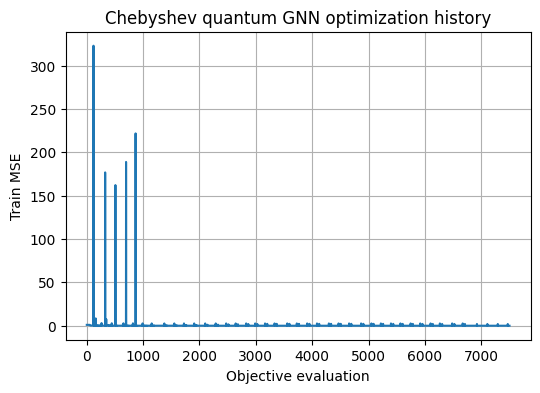

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(train_history)
plt.xlabel("Objective evaluation")
plt.ylabel("Train MSE")
plt.title("Chebyshev quantum GNN optimization history")
plt.grid(True)
plt.show()

In [27]:
cheb_y_pred_train = predict_dataset(cheb_qgnn, graph_input, X_train)
cheb_y_pred_test = predict_dataset(cheb_qgnn, graph_input, X_test)

cheb_metrics_df = pd.DataFrame(
    {
        "split": ["train", "train", "train", "test", "test", "test"],
        "metric": ["MAE", "RMSE", "R2", "MAE", "RMSE", "R2"],
        "value": [
            mae_metric(cheb_y_pred_train, Y_train),
            rmse_metric(cheb_y_pred_train, Y_train),
            r2_metric(cheb_y_pred_train, Y_train),
            mae_metric(cheb_y_pred_test, Y_test),
            rmse_metric(cheb_y_pred_test, Y_test),
            r2_metric(cheb_y_pred_test, Y_test),
        ],
    }
)

cheb_metrics_df

,split,metric,value
0,train,MAE,0.001515
1,train,RMSE,0.001736
2,train,R2,0.139961
3,test,MAE,0.001532
4,test,RMSE,0.001754
5,test,R2,0.047021


### True vs predicted (one sample)

In [28]:
sample_x = X_test[0]

cheb_coeffs_1 = cheb_provider_1.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=3,)
cheb_coeffs_2 = cheb_provider_2.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=3,)
#print("Learned layer-1 Chebyshev coefficients:", cheb_coeffs_1)
#print("Learned layer-2 Chebyshev coefficients:", cheb_coeffs_2)

In [29]:
cheb_sample_idx = 0
cheb_x_sample = X_test[cheb_sample_idx].reshape(-1)
cheb_y_true = Y_test[cheb_sample_idx].reshape(-1)
cheb_y_pred = cheb_y_pred_test[cheb_sample_idx].reshape(-1)

cheb_comparison_df = pd.DataFrame(
    {
        "bus": topology_bundle.node_order,
        "load_p_mw": cheb_x_sample,
        "true_vm_pu": cheb_y_true,
        "predicted_vm_pu": cheb_y_pred,
        "abs_error": np.abs(cheb_y_true - cheb_y_pred),
    }
)

cheb_comparison_df

,bus,load_p_mw,true_vm_pu,predicted_vm_pu,abs_error
0,0,0.000000,1.000000,0.998216,0.001784
1,1,1.016569,0.998388,0.995172,0.003216
2,2,0.305278,0.997464,0.998946,0.001482
3,3,0.266559,0.996745,0.997868,0.001123
4,4,0.794434,0.996207,0.995735,0.000472


In [30]:
cheb_display_net = copy.deepcopy(base_net)
cheb_test_sample_global_idx = n_train + cheb_sample_idx
cheb_sample_loads = X[cheb_test_sample_global_idx, :, 0]
for load_idx, bus_idx in zip(cheb_display_net.load.index,cheb_display_net.load["bus"].to_numpy(),):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(cheb_sample_loads[bus_idx])
    cheb_display_net.load.loc[load_idx, "p_mw"] = p
    cheb_display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

cheb_display_bundle = pandapower_to_graph_bundle(cheb_display_net,node_feature_specs=["load_p_mw"], 
                                                 edge_feature_specs=["loading_percent"],run_powerflow=True,)

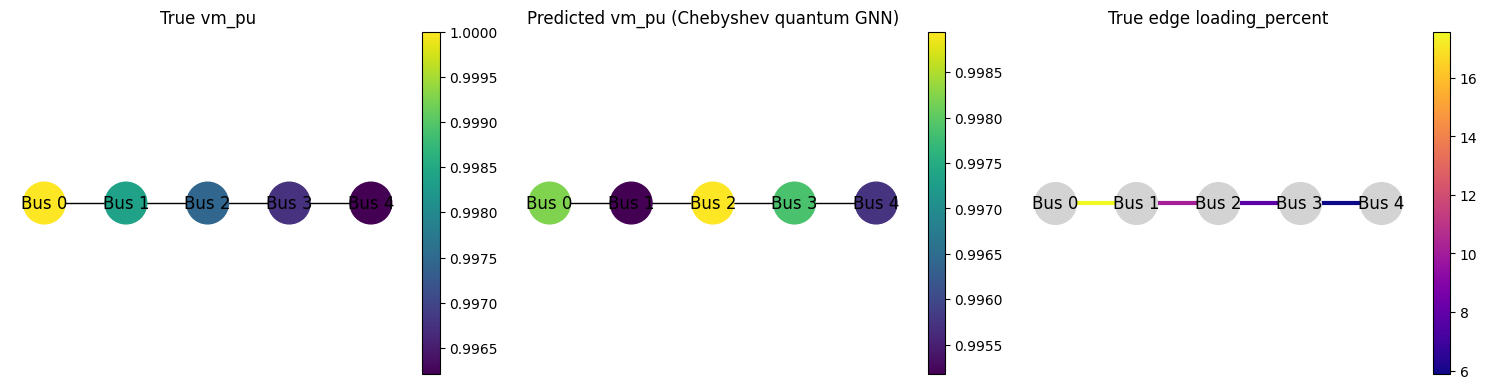

In [31]:
cheb_edge_values = np.asarray([cheb_display_bundle.edge_features[tuple(sorted((u, v)))][0] for u, v in cheb_display_bundle.graph.edges()],
                              dtype=float,)

display_graph_signal_comparison(G=cheb_display_bundle.graph, node_order=cheb_display_bundle.node_order,
                                input_node_values=cheb_y_true,output_node_values=cheb_y_pred,edge_values=cheb_edge_values,
                                node_labels=cheb_display_bundle.node_labels,layout="line",input_title="True vm_pu",
                                output_title="Predicted vm_pu (Chebyshev quantum GNN)",edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

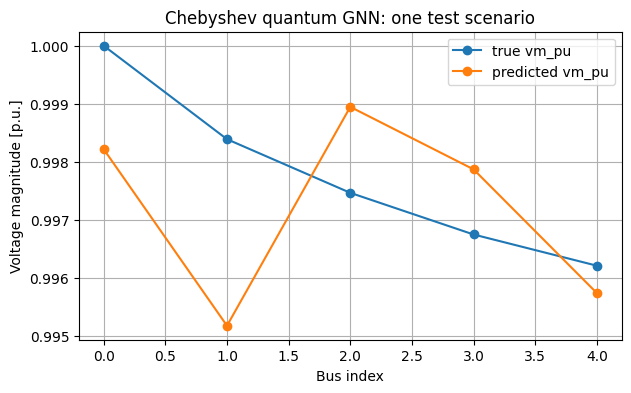

In [32]:
plt.figure(figsize=(7, 4))
plt.plot(topology_bundle.node_order, cheb_y_true, marker="o", label="true vm_pu")
plt.plot(topology_bundle.node_order, cheb_y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("Chebyshev quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()

## PolynomialBlockEncodingQuantumGraphFilter

We now apply the `PolynomialBlockEncodingQuantumGraphFilter`, which works as the previous Chebyshev approximatin, but here the expansion is given in terms of powers of the adjusted Laplacian $\tilde{L}$. Notice that for most combinations of Pauli matrices as Laplacians, this filter is essentially equivalent to the previous one. To fix the ideas, aslo in this case, we consider 3 coefficients per layer.

In [33]:
poly_provider_1 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,output_scale=1.0,normalize_coefficients=False,)
poly_provider_2 = QiskitVariationalCoefficientProvider(num_qubits=2,num_layers=1,input_scale=0.5,output_scale=1.0,normalize_coefficients=False,)

poly_filter_1 = PolynomialBlockEncodingQuantumGraphFilter(coefficients=[1.0, 0.0, 0.0],rescale_laplacian=True,coefficient_provider=poly_provider_1,
                                                          operator_scale=None,renormalize_by_success_probability=False,)
poly_filter_2 = PolynomialBlockEncodingQuantumGraphFilter(coefficients=[1.0, 0.0, 0.0],rescale_laplacian=True,coefficient_provider=poly_provider_2,
                                                          operator_scale=None,renormalize_by_success_probability=False,)

poly_qgnn = TwoLayerQuantumGraphNetwork(in_features=1,hidden_features=4,out_features=1,first_filter=poly_filter_1,second_filter=poly_filter_2,random_state=42,)

### Training and test

In [34]:
poly_initial_params = pack_parameters(poly_qgnn,poly_provider_1,poly_provider_2,)
poly_y_pred_train_init = predict_dataset(poly_qgnn, graph_input, X_train)
poly_y_pred_test_init = predict_dataset(poly_qgnn, graph_input, X_test)
#print("Initial polynomial train MSE:", mse_loss(poly_y_pred_train_init, Y_train))
#print("Initial polynomial test  MSE:", mse_loss(poly_y_pred_test_init, Y_test))

In [37]:
train_history = []
def objective_function(param_vector):
    """
    Training objective for the two-layer polynomial quantum GNN.
    """
    unpack_parameters(param_vector,poly_qgnn,poly_provider_1,poly_provider_2,)
    poly_y_pred_train = predict_dataset(poly_qgnn, graph_input, X_train)
    loss = mse_loss(poly_y_pred_train, Y_train)
    train_history.append(loss)
    return loss

In [38]:
poly_result = minimize(objective_function,x0=poly_initial_params,method="Powell",options={"maxiter": 60,"disp": True,},)
poly_best_params = poly_result.x.copy()
unpack_parameters(poly_best_params,poly_qgnn,poly_provider_1,poly_provider_2,)
print("Optimization success:", poly_result.success)
print("Final training loss:", poly_result.fun)
print("Message:", poly_result.message)

Optimization terminated successfully.
         Current function value: 0.000001
         Iterations: 35
         Function evaluations: 6677
Optimization success: True
Final training loss: 1.4135791279003248e-06
Message: Optimization terminated successfully.


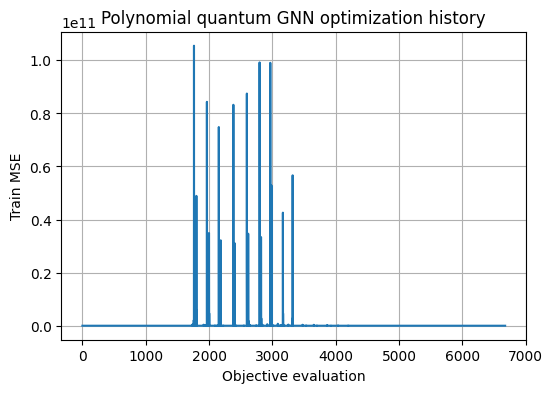

In [39]:
plt.figure(figsize=(6, 4))
plt.plot(train_history)
plt.xlabel("Objective evaluation")
plt.ylabel("Train MSE")
plt.title("Polynomial quantum GNN optimization history")
plt.grid(True)
plt.show()

In [40]:
poly_y_pred_train = predict_dataset(poly_qgnn, graph_input, X_train)
poly_y_pred_test = predict_dataset(poly_qgnn, graph_input, X_test)

poly_metrics_df = pd.DataFrame(
    {
        "split": ["train", "train", "train", "test", "test", "test"],
        "metric": ["MAE", "RMSE", "R2", "MAE", "RMSE", "R2"],
        "value": [
            mae_metric(poly_y_pred_train, Y_train),
            rmse_metric(poly_y_pred_train, Y_train),
            r2_metric(poly_y_pred_train, Y_train),
            mae_metric(poly_y_pred_test, Y_test),
            rmse_metric(poly_y_pred_test, Y_test),
            r2_metric(poly_y_pred_test, Y_test),
        ],
    }
)

poly_metrics_df

,split,metric,value
0,train,MAE,0.000962
1,train,RMSE,0.001189
2,train,R2,0.596762
3,test,MAE,0.001069
4,test,RMSE,0.001316
5,test,R2,0.463619


### True vs predicted (one sample)

In [41]:
sample_x = X_test[0]
poly_coeffs_1 = poly_provider_1.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=3,)
poly_coeffs_2 = poly_provider_2.get_coefficients(graph_input=graph_input,features=sample_x,num_coefficients=3,)
#print("Learned layer-1 polynomial coefficients:", poly_coeffs_1)
#print("Learned layer-2 polynomial coefficients:", poly_coeffs_2)

In [42]:
poly_sample_idx = 0
poly_x_sample = X_test[poly_sample_idx].reshape(-1)
poly_y_true = Y_test[poly_sample_idx].reshape(-1)
poly_y_pred = poly_y_pred_test[poly_sample_idx].reshape(-1)

poly_comparison_df = pd.DataFrame(
    {
        "bus": topology_bundle.node_order,
        "load_p_mw": poly_x_sample,
        "true_vm_pu": poly_y_true,
        "predicted_vm_pu": poly_y_pred,
        "abs_error": np.abs(poly_y_true - poly_y_pred),
    }
)

poly_comparison_df

,bus,load_p_mw,true_vm_pu,predicted_vm_pu,abs_error
0,0,0.000000,1.000000,0.998737,0.001263
1,1,1.016569,0.998388,0.995887,0.002501
2,2,0.305278,0.997464,0.997325,0.000139
3,3,0.266559,0.996745,0.997106,0.000360
4,4,0.794434,0.996207,0.996794,0.000586


In [43]:
poly_display_net = copy.deepcopy(base_net)
poly_test_sample_global_idx = n_train + poly_sample_idx
poly_sample_loads = X[poly_test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(poly_display_net.load.index,poly_display_net.load["bus"].to_numpy(),):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(poly_sample_loads[bus_idx])
    poly_display_net.load.loc[load_idx, "p_mw"] = p
    poly_display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

poly_display_bundle = pandapower_to_graph_bundle(poly_display_net,node_feature_specs=["load_p_mw"],edge_feature_specs=["loading_percent"],run_powerflow=True,)

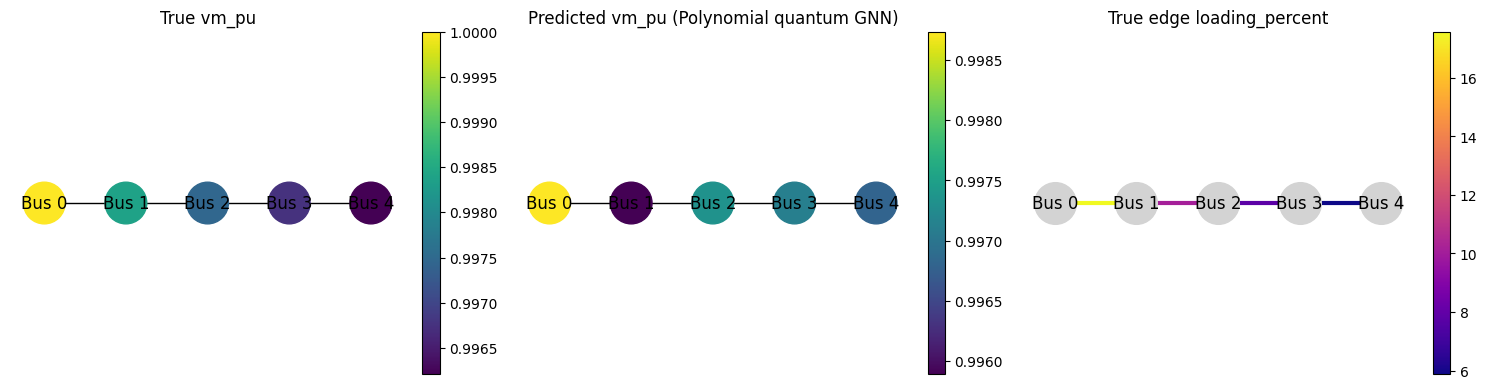

In [44]:
poly_edge_values = np.asarray([poly_display_bundle.edge_features[tuple(sorted((u, v)))][0]for u, v in poly_display_bundle.graph.edges()],
                              dtype=float,)

display_graph_signal_comparison(G=poly_display_bundle.graph,node_order=poly_display_bundle.node_order,input_node_values=poly_y_true,
                                output_node_values=poly_y_pred,edge_values=poly_edge_values,node_labels=poly_display_bundle.node_labels,
                                layout="line",input_title="True vm_pu",output_title="Predicted vm_pu (Polynomial quantum GNN)",
                                edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

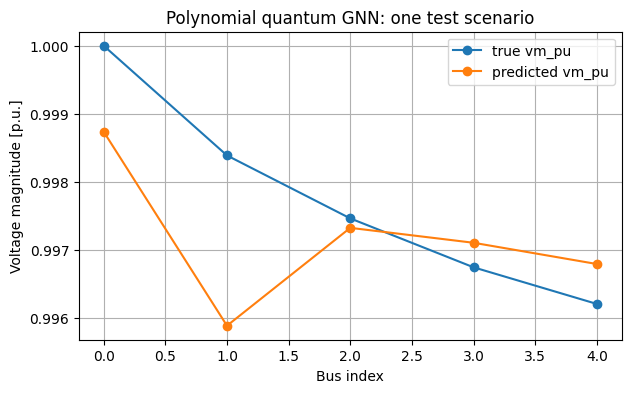

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(topology_bundle.node_order, poly_y_true, marker="o", label="true vm_pu")
plt.plot(topology_bundle.node_order, poly_y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("Polynomial quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()

## ExponentialQuantumGraphFilter

This class of filters implement the quantum spectral evolution $X\to e^{-i\alpha \tilde{L}} X$ where $\tilde{L}=I-$`graph_input.kipf_welling_adjacency()` (up to a global factor $\frac{2}{\lambda_{\max}}$ that normalizes, via the maximum eigenvalue of the adjacency matrix $\lambda_{\max}$, the spectrum of the adjusted Laplacian $\tilde{L}$). The main properties of this filter arise from the "Taylor" matrix expansion $e^{-i\alpha \tilde{L}}\approx I + i\alpha \tilde{L}+\frac{\alpha^2\tilde{L}}{2}+\dots$. Just to fix the ideas consider the case of a line graph $G$ with two nodes and one edge, then $$\tilde{L}=\frac{2}{\lambda_{\max}}(I-\begin{pmatrix}0&1\\1&0\end{pmatrix})=-X$$ where $X$ is the $x$-Pauli matrix. In this case $e^{-i\alpha\tilde{L}}$ is a rotation (so we don't need block-encodings or other means to embed a non-unitary evolution into a unitary one) which "reproduces"" the classical Chebyshev approximation in the Kipf-Welling layer. Indeed, the first Chebyshev polynomials applyied to $\tilde{L}$ read $T_0(\tilde{L})=I$, $T_1(\tilde{L})=-X$, $T_2(\tilde{L})=2(-X)^2-I=I$, $T_3(\tilde{L})=4(-X)^3-3(-X)=-X$, etc... Up to a global phase we thus have that the first order approximation of the unitary evolution $X\to e^{-i\alpha\tilde{L}}X$ is exactly the first order approximation in the Chebyshev expansion defining the Kipf-Welling filter. Tuning the angle $\alpha$ it is possible to have also good higher order approximations, but, eventually, this "symmetry breaks" and the two message passing are essentially different. Thus, this filter is essentially different from the previous ones: the trainable part is the two linear heads in the `QuantumGraphLayer`s while the functional form of the filter is fixed by $\alpha$ and `rescale_laplacian`. 

We still compare this approach to the previous ones on the same kind of task and dataset.

In [46]:
exp_filter_1 = ExponentialQuantumGraphFilter(alpha=0.8,rescale_laplacian=True,)
exp_filter_2 = ExponentialQuantumGraphFilter(alpha=0.5,rescale_laplacian=True,)
exp_qgnn = TwoLayerQuantumGraphNetwork(in_features=1,hidden_features=4,out_features=1,first_filter=exp_filter_1,
                                       second_filter=exp_filter_2,random_state=42,)

In [47]:
exp_output_init = exp_qgnn.forward(graph_input, features=X_train[0])
exp_output_init = np.asarray(exp_output_init, dtype=np.float64)
#print("Initial exponential output shape:", exp_output_init.shape)
#print("Initial exponential output:")
#print(exp_output_init.reshape(-1))

### Training and test

In [51]:
def pack_exponential_parameters(exp_qgnn):
    """
    Flatten trainable parameters for the two-layer exponential quantum GNN.
    """
    parts = [exp_qgnn.layer1.weight.reshape(-1),exp_qgnn.layer1.bias.reshape(-1),
             exp_qgnn.layer2.weight.reshape(-1),exp_qgnn.layer2.bias.reshape(-1),]
    return np.concatenate(parts).astype(np.float64)

def unpack_exponential_parameters(param_vector, exp_qgnn):
    """
    Write a flat parameter vector back into the two-layer exponential quantum GNN.
    """
    idx = 0
    n_w1 = exp_qgnn.layer1.weight.size
    exp_qgnn.layer1.weight = (param_vector[idx:idx + n_w1].reshape(exp_qgnn.layer1.weight.shape).copy())
    idx += n_w1
    n_b1 = exp_qgnn.layer1.bias.size
    exp_qgnn.layer1.bias = (param_vector[idx:idx + n_b1].reshape(exp_qgnn.layer1.bias.shape).copy())
    idx += n_b1
    n_w2 = exp_qgnn.layer2.weight.size
    exp_qgnn.layer2.weight = (param_vector[idx:idx + n_w2].reshape(exp_qgnn.layer2.weight.shape).copy())
    idx += n_w2
    n_b2 = exp_qgnn.layer2.bias.size
    exp_qgnn.layer2.bias = (param_vector[idx:idx + n_b2].reshape(exp_qgnn.layer2.bias.shape).copy())
    idx += n_b2

In [52]:
exp_initial_params = pack_exponential_parameters(exp_qgnn)
exp_y_pred_train_init = predict_dataset(exp_qgnn, graph_input, X_train)
exp_y_pred_test_init = predict_dataset(exp_qgnn, graph_input, X_test)
#print("Initial exponential train MSE:", mse_loss(exp_y_pred_train_init, Y_train))
#print("Initial exponential test  MSE:", mse_loss(exp_y_pred_test_init, Y_test))

In [56]:
train_history = []
def objective_function(param_vector):
    """
    Training objective for the two-layer exponential quantum GNN.
    """
    unpack_exponential_parameters(param_vector, exp_qgnn)
    exp_y_pred_train = predict_dataset(exp_qgnn, graph_input, X_train)
    loss = mse_loss(exp_y_pred_train, Y_train)
    train_history.append(loss)
    return loss

In [58]:
exp_result = minimize(objective_function, x0=exp_initial_params,method="Powell",options={"maxiter": 100,"disp": True,},)
exp_best_params = exp_result.x.copy()
unpack_exponential_parameters(exp_best_params,exp_qgnn,)
print("Optimization success:", exp_result.success)
print("Final training loss:", exp_result.fun)
print("Message:", exp_result.message)

Optimization terminated successfully.
         Current function value: 0.000001
         Iterations: 86
         Function evaluations: 12427
Optimization success: True
Final training loss: 1.3754313515917566e-06
Message: Optimization terminated successfully.


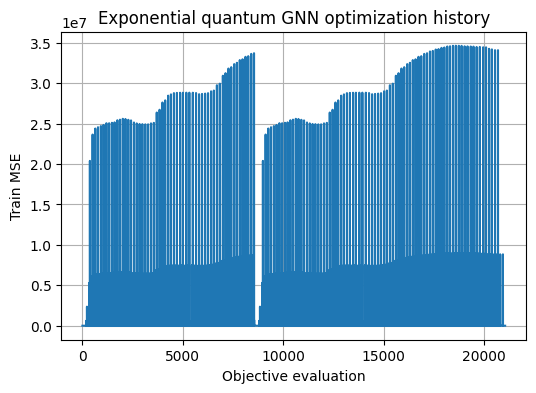

In [59]:
plt.figure(figsize=(6, 4))
plt.plot(train_history)
plt.xlabel("Objective evaluation")
plt.ylabel("Train MSE")
plt.title("Exponential quantum GNN optimization history")
plt.grid(True)
plt.show()

In [60]:
exp_y_pred_train = predict_dataset(exp_qgnn, graph_input, X_train)
exp_y_pred_test = predict_dataset(exp_qgnn, graph_input, X_test)

exp_metrics_df = pd.DataFrame(
    {
        "split": ["train", "train", "train", "test", "test", "test"],
        "metric": ["MAE", "RMSE", "R2", "MAE", "RMSE", "R2"],
        "value": [
            mae_metric(exp_y_pred_train, Y_train),
            rmse_metric(exp_y_pred_train, Y_train),
            r2_metric(exp_y_pred_train, Y_train),
            mae_metric(exp_y_pred_test, Y_test),
            rmse_metric(exp_y_pred_test, Y_test),
            r2_metric(exp_y_pred_test, Y_test),
        ],
    }
)

exp_metrics_df

,split,metric,value
0,train,MAE,0.000899
1,train,RMSE,0.001173
2,train,R2,0.607644
3,test,MAE,0.000875
4,test,RMSE,0.001186
5,test,R2,0.564498


### True vs predicted (one sample)

In [61]:
exp_sample_idx = 0
exp_x_sample = X_test[exp_sample_idx].reshape(-1)
exp_y_true = Y_test[exp_sample_idx].reshape(-1)
exp_y_pred = exp_y_pred_test[exp_sample_idx].reshape(-1)

exp_comparison_df = pd.DataFrame(
    {
        "bus": topology_bundle.node_order,
        "load_p_mw": exp_x_sample,
        "true_vm_pu": exp_y_true,
        "predicted_vm_pu": exp_y_pred,
        "abs_error": np.abs(exp_y_true - exp_y_pred),
    }
)

exp_comparison_df

,bus,load_p_mw,true_vm_pu,predicted_vm_pu,abs_error
0,0,0.000000,1.000000,0.999970,2.954855e-05
1,1,1.016569,0.998388,0.995924,2.464389e-03
2,2,0.305278,0.997464,0.996932,5.311980e-04
3,3,0.266559,0.996745,0.997096,3.504753e-04
4,4,0.794434,0.996207,0.996206,7.872548e-07


In [62]:
exp_display_net = copy.deepcopy(base_net)
exp_test_sample_global_idx = n_train + exp_sample_idx
exp_sample_loads = X[exp_test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(
    exp_display_net.load.index,
    exp_display_net.load["bus"].to_numpy(),
):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(exp_sample_loads[bus_idx])
    exp_display_net.load.loc[load_idx, "p_mw"] = p
    exp_display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

exp_display_bundle = pandapower_to_graph_bundle(exp_display_net,node_feature_specs=["load_p_mw"],edge_feature_specs=["loading_percent"],run_powerflow=True,)

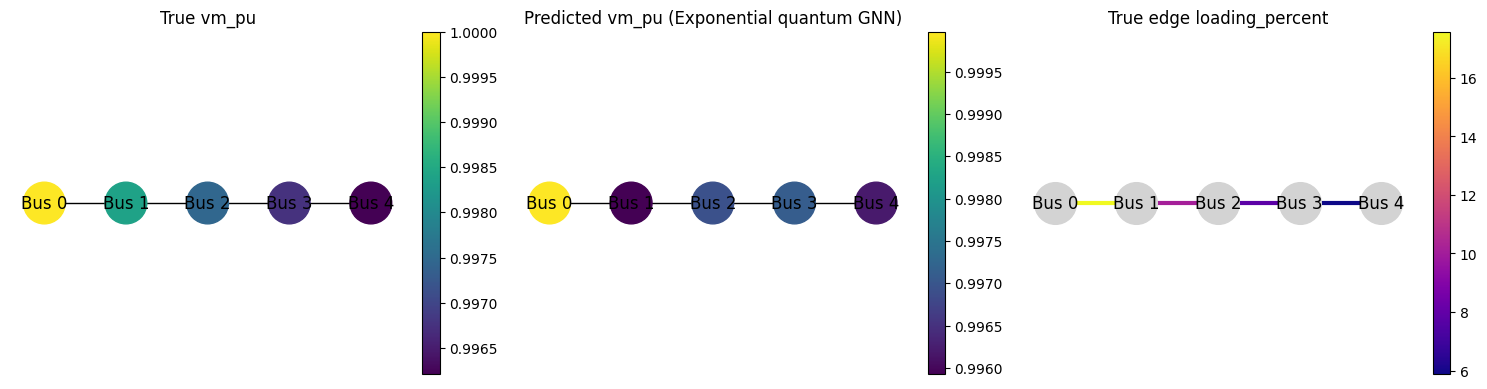

In [63]:
exp_edge_values = np.asarray([exp_display_bundle.edge_features[tuple(sorted((u, v)))][0]for u, v in exp_display_bundle.graph.edges()],
                             dtype=float,)
display_graph_signal_comparison(G=exp_display_bundle.graph,node_order=exp_display_bundle.node_order,input_node_values=exp_y_true,
                                output_node_values=exp_y_pred,edge_values=exp_edge_values,node_labels=exp_display_bundle.node_labels,
                                layout="line",input_title="True vm_pu",output_title="Predicted vm_pu (Exponential quantum GNN)",
                                edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

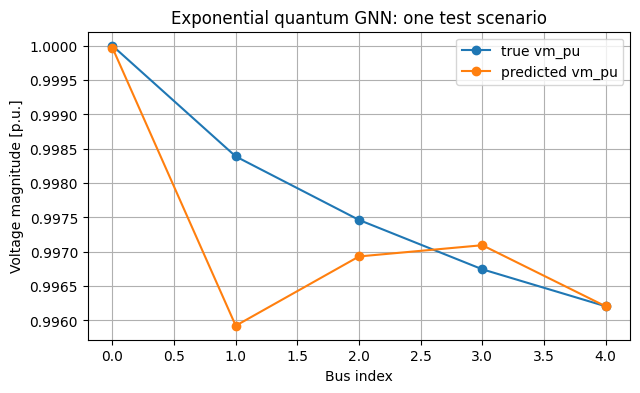

In [64]:
plt.figure(figsize=(7, 4))
plt.plot(topology_bundle.node_order, exp_y_true, marker="o", label="true vm_pu")
plt.plot(topology_bundle.node_order, exp_y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("Exponential quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()

## MimicQuantumGraphFilter

Let's conclude with the last family of filters, the `MimicQuantumGraphFilter`s. In this case we have a surrogate model $X\to \beta X+\sum_k w_k\Phi(\alpha_k,L)X$ where $L$ is a graph-aware operator (e.g., the Laplacian), $\beta$ is a "resiudal" coefficient, $w_k$ are "mixture" coefficients and $\alpha_k$ represent "evolution time". The term $\Phi=\Phi(\alpha_k, L)$ is the propagation step induced by a quantum evolution at time $\alpha_k$ via the (encoding of) the matrix $L$. In the code, the first choices for $L$ can be a rescaled laplacian (when `rescale_laplacian = True`) or the encoding of the standard Kipf-Welling filter (coming from the abstraction `GraphInput`). What this filters effectively do is:
- unitary evolutions $U(\alpha_*)=e^{-i\alpha_xL}$;
- for each feature $x$, normalize $x\to \hat{x}=x||x||^{-1}$;
- pad if necessary (both $L$ and $\hat{x}$) $\hat{x}\to \hat{\hat{x}}, L\to \hat{L}$ and $U\to \hat{U}$;
- carry out the message passing $\hat{x}\to \hat{U}(\alpha_*)\hat{\hat{x}}$;
- decode back to the "graph space" via the approximation $x\to \Phi(\alpha,L)x\approx ||x||Re(\hat{U}(\alpha_*)\hat{\hat{x}})$.

The main difference between this approach and the previous ones is that we can "mixture" several evolutions: instead of choosing a single $\alpha$ as in the exponential encoding seen above, the filter can combine several responses by using different evolutions at different times. In this sense this approach can "mimic" the target matrix function $g(L)\approx \beta I+\sum_k w_ke^{-i\alpha_k L}$ keeping only the real part. Using the identity $e^{-i\alpha L}=\cos(\alpha L)-i\sin(\alpha L)$ we are thus left with $\cos(\alpha L)$ (modulo padding), recovering in this sense a "Chebyshev" expansion where instead of expandin around $L$ we expand around the evolution $e^{i\alpha L}$.

Also in this case we can get the parameters with a quantum circuits, for simplicity's sake in this case we keep them fixed.

In [65]:
mimic_filter_1 = MimicQuantumGraphFilter(evolution_times=[0.4, 0.9],mixture_coefficients=[0.7, -0.2],
                                         residual_coefficient=0.6,rescale_laplacian=True,take_real_part=True,subtract_identity_from_evolution=False,)
mimic_filter_2 = MimicQuantumGraphFilter(evolution_times=[0.3, 0.8],mixture_coefficients=[0.5, -0.1],residual_coefficient=0.4,
                                         rescale_laplacian=True,take_real_part=True,subtract_identity_from_evolution=False,)
mimic_qgnn = TwoLayerQuantumGraphNetwork(in_features=1,hidden_features=4,out_features=1,first_filter=mimic_filter_1,second_filter=mimic_filter_2,random_state=42,)

In [66]:
mimic_output_init = mimic_qgnn.forward(graph_input, features=X_train[0])
mimic_output_init = np.asarray(mimic_output_init, dtype=np.float64)
#print("Initial mimic output shape:", mimic_output_init.shape)
#print("Initial mimic output:")
#print(mimic_output_init.reshape(-1))

## Train and test

In [67]:
def pack_mimic_parameters(mimic_qgnn):
    """
    Flatten trainable parameters for the two-layer mimic quantum GNN.
    """
    parts = [
        mimic_qgnn.layer1.weight.reshape(-1),
        mimic_qgnn.layer1.bias.reshape(-1),
        mimic_qgnn.layer2.weight.reshape(-1),
        mimic_qgnn.layer2.bias.reshape(-1),
    ]
    return np.concatenate(parts).astype(np.float64)


def unpack_mimic_parameters(param_vector, mimic_qgnn):
    """
    Write a flat parameter vector back into the two-layer mimic quantum GNN.
    """
    idx = 0
    n_w1 = mimic_qgnn.layer1.weight.size
    mimic_qgnn.layer1.weight = (param_vector[idx:idx + n_w1].reshape(mimic_qgnn.layer1.weight.shape).copy())
    idx += n_w1
    n_b1 = mimic_qgnn.layer1.bias.size
    mimic_qgnn.layer1.bias = (param_vector[idx:idx + n_b1].reshape(mimic_qgnn.layer1.bias.shape).copy())
    idx += n_b1
    n_w2 = mimic_qgnn.layer2.weight.size
    mimic_qgnn.layer2.weight = (param_vector[idx:idx + n_w2].reshape(mimic_qgnn.layer2.weight.shape).copy())
    idx += n_w2
    n_b2 = mimic_qgnn.layer2.bias.size
    mimic_qgnn.layer2.bias = (param_vector[idx:idx + n_b2].reshape(mimic_qgnn.layer2.bias.shape).copy())
    idx += n_b2

In [68]:
mimic_initial_params = pack_mimic_parameters(mimic_qgnn)
mimic_y_pred_train_init = predict_dataset(mimic_qgnn, graph_input, X_train)
mimic_y_pred_test_init = predict_dataset(mimic_qgnn, graph_input, X_test)
#print("Initial mimic train MSE:", mse_loss(mimic_y_pred_train_init, Y_train))
#print("Initial mimic test  MSE:", mse_loss(mimic_y_pred_test_init, Y_test))

In [69]:
mimic_train_history = []
def objective_function(param_vector):
    """
    Training objective for the two-layer mimic quantum GNN.
    """
    unpack_mimic_parameters(param_vector, mimic_qgnn)
    mimic_y_pred_train = predict_dataset(mimic_qgnn, graph_input, X_train)
    loss = mse_loss(mimic_y_pred_train, Y_train)
    mimic_train_history.append(loss)
    return loss

In [70]:
mimic_result = minimize(objective_function,x0=mimic_initial_params,method="Powell",options={"maxiter": 60,"disp": True,},)
mimic_best_params = mimic_result.x.copy()
unpack_mimic_parameters(mimic_best_params,mimic_qgnn,)
print("Optimization success:", mimic_result.success)
print("Final training loss:", mimic_result.fun)
print("Message:", mimic_result.message)

Optimization terminated successfully.
         Current function value: 0.000002
         Iterations: 10
         Function evaluations: 1429
Optimization success: True
Final training loss: 1.775912654299189e-06
Message: Optimization terminated successfully.


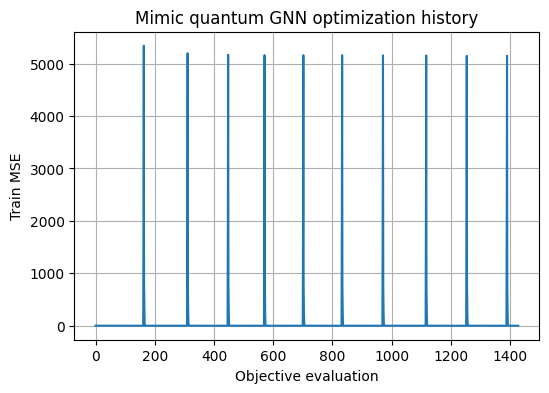

In [71]:
plt.figure(figsize=(6, 4))
plt.plot(mimic_train_history)
plt.xlabel("Objective evaluation")
plt.ylabel("Train MSE")
plt.title("Mimic quantum GNN optimization history")
plt.grid(True)
plt.show()

In [72]:
mimic_y_pred_train = predict_dataset(mimic_qgnn, graph_input, X_train)
mimic_y_pred_test = predict_dataset(mimic_qgnn, graph_input, X_test)

mimic_metrics_df = pd.DataFrame(
    {
        "split": ["train", "train", "train", "test", "test", "test"],
        "metric": ["MAE", "RMSE", "R2", "MAE", "RMSE", "R2"],
        "value": [
            mae_metric(mimic_y_pred_train, Y_train),
            rmse_metric(mimic_y_pred_train, Y_train),
            r2_metric(mimic_y_pred_train, Y_train),
            mae_metric(mimic_y_pred_test, Y_test),
            rmse_metric(mimic_y_pred_test, Y_test),
            r2_metric(mimic_y_pred_test, Y_test),
        ],
    }
)

mimic_metrics_df

,split,metric,value
0,train,MAE,0.001127
1,train,RMSE,0.001333
2,train,R2,0.493403
3,test,MAE,0.001161
4,test,RMSE,0.001417
5,test,R2,0.377746


### True vs predicted (one sample)

In [73]:
mimic_sample_idx = 0
mimic_x_sample = X_test[mimic_sample_idx].reshape(-1)
mimic_y_true = Y_test[mimic_sample_idx].reshape(-1)
mimic_y_pred = mimic_y_pred_test[mimic_sample_idx].reshape(-1)

mimic_comparison_df = pd.DataFrame(
    {
        "bus": topology_bundle.node_order,
        "load_p_mw": mimic_x_sample,
        "true_vm_pu": mimic_y_true,
        "predicted_vm_pu": mimic_y_pred,
        "abs_error": np.abs(mimic_y_true - mimic_y_pred),
    }
)

mimic_comparison_df

,bus,load_p_mw,true_vm_pu,predicted_vm_pu,abs_error
0,0,0.000000,1.000000,0.998864,0.001136
1,1,1.016569,0.998388,0.995314,0.003074
2,2,0.305278,0.997464,0.999497,0.002033
3,3,0.266559,0.996745,0.998681,0.001935
4,4,0.794434,0.996207,0.995292,0.000915


In [75]:
mimic_display_net = copy.deepcopy(base_net)
mimic_test_sample_global_idx = n_train + mimic_sample_idx
mimic_sample_loads = X[mimic_test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(mimic_display_net.load.index,mimic_display_net.load["bus"].to_numpy(),):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(mimic_sample_loads[bus_idx])
    mimic_display_net.load.loc[load_idx, "p_mw"] = p
    mimic_display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

mimic_display_bundle = pandapower_to_graph_bundle(mimic_display_net,node_feature_specs=["load_p_mw"],edge_feature_specs=["loading_percent"], run_powerflow=True,)

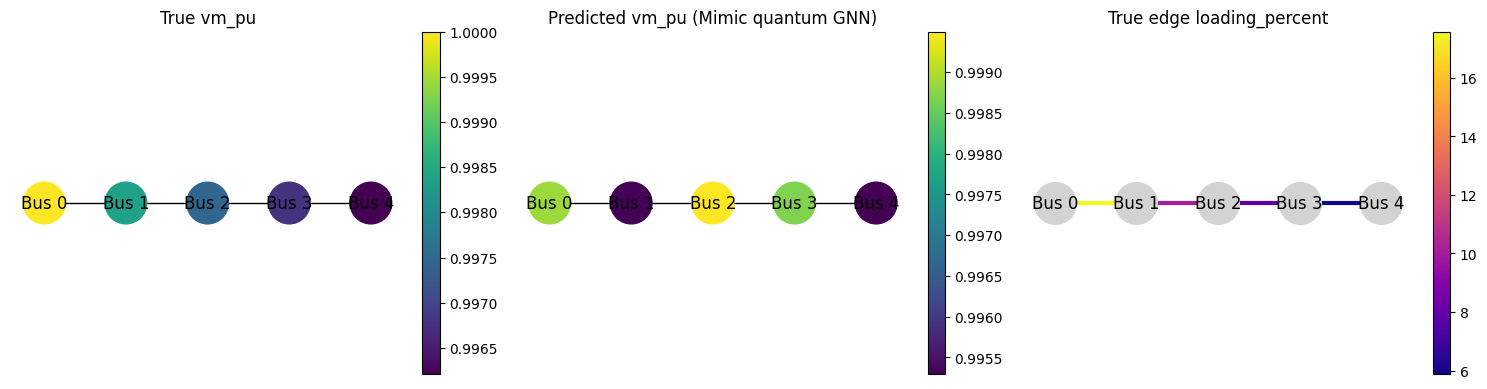

In [76]:
mimic_edge_values = np.asarray([mimic_display_bundle.edge_features[tuple(sorted((u, v)))][0] for u, v in mimic_display_bundle.graph.edges()],
                               dtype=float,)

display_graph_signal_comparison(G=mimic_display_bundle.graph,node_order=mimic_display_bundle.node_order,input_node_values=mimic_y_true,
                                output_node_values=mimic_y_pred,edge_values=mimic_edge_values,node_labels=mimic_display_bundle.node_labels,
                                layout="line",input_title="True vm_pu",output_title="Predicted vm_pu (Mimic quantum GNN)",
                                edge_title="True edge loading_percent",figsize=(15.0, 4.0),)

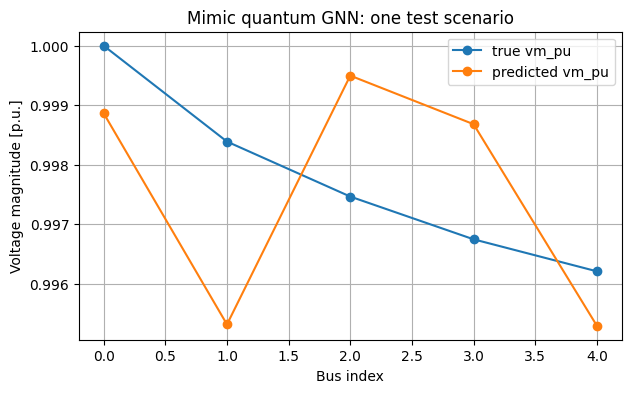

In [77]:
plt.figure(figsize=(7, 4))
plt.plot(topology_bundle.node_order, mimic_y_true, marker="o", label="true vm_pu")
plt.plot(topology_bundle.node_order, mimic_y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("Mimic quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()